# Individual Test Usage

This notebook demonstrates how to run each stationarity test independently.
Use this when you only need specific tests rather than the full toolkit.

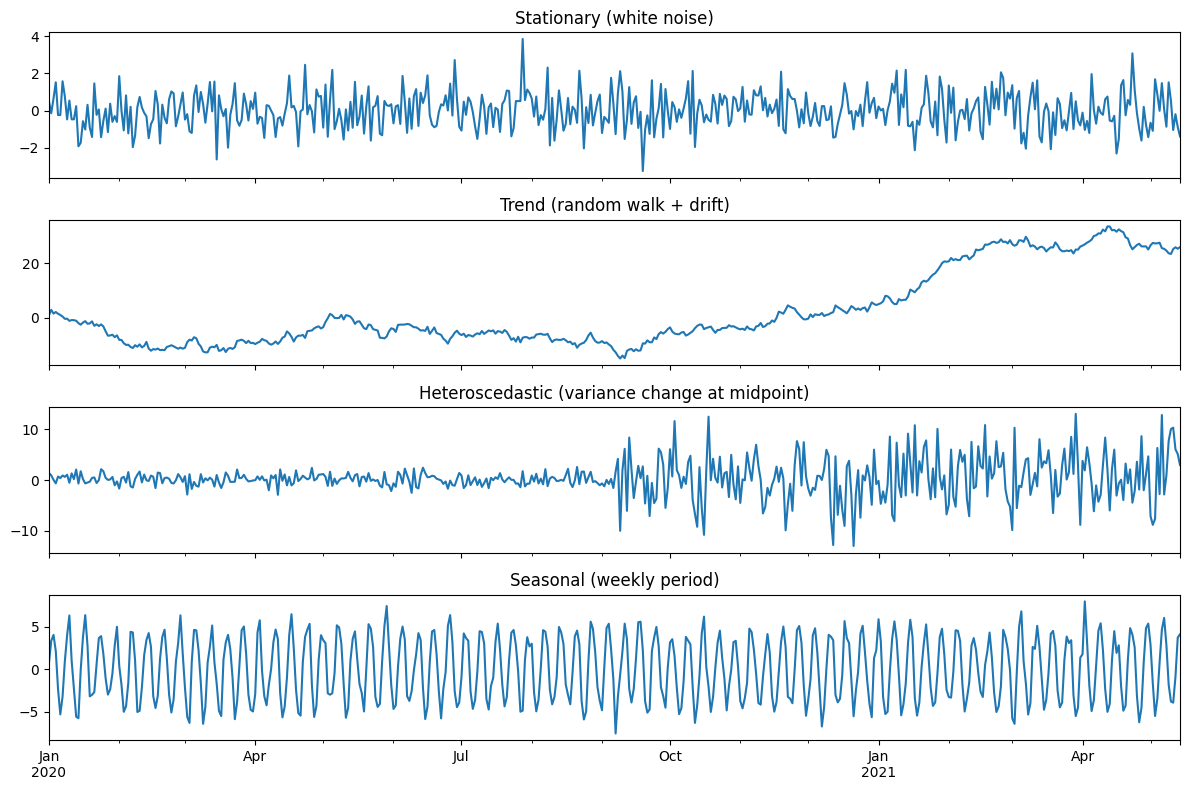

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Create sample time series
np.random.seed(42)
n = 500
dates = pd.date_range('2020-01-01', periods=n, freq='D')

# Stationary series (white noise)
ts_stationary = pd.Series(np.random.randn(n), index=dates)

# Non-stationary series (random walk + trend)
ts_trend = pd.Series(np.cumsum(np.random.randn(n)) + np.linspace(0, 10, n), index=dates)

# Series with changing variance
variance = np.concatenate([np.ones(250), np.ones(250) * 5])
ts_hetero = pd.Series(np.random.randn(n) * variance, index=dates)

# Series with seasonality
ts_seasonal = pd.Series(np.random.randn(n) + 5 * np.sin(2 * np.pi * np.arange(n) / 7), index=dates)

# Plot all series
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
ts_stationary.plot(ax=axes[0], title='Stationary (white noise)')
ts_trend.plot(ax=axes[1], title='Trend (random walk + drift)')
ts_hetero.plot(ax=axes[2], title='Heteroscedastic (variance change at midpoint)')
ts_seasonal.plot(ax=axes[3], title='Seasonal (weekly period)')
plt.tight_layout()
plt.show()

## Trend Tests

In [39]:
from stationarity_toolkit.tests.trend import adf_test, kpss_test, phillips_perron_test, zivot_andrews_test

In [40]:
# ADF - tests for unit roots
result = adf_test(ts_stationary)
print(f"ADF on stationary: is_stationary={result.is_stationary}, p={result.p_value:.4f}")
print(f"  Note: {result.educational_note}")

result = adf_test(ts_trend)
print(f"\nADF on trend: is_stationary={result.is_stationary}, p={result.p_value:.4f}")
print(f"  Note: {result.educational_note}")

ADF on stationary: is_stationary=True, p=0.0000
  Note: Stationary around constant mean

ADF on trend: is_stationary=False, p=0.9686
  Note: Unit root detected - consider differencing


In [41]:
# KPSS - reverse null hypothesis (null = stationary)
result = kpss_test(ts_stationary)
print(f"KPSS on stationary: is_stationary={result.is_stationary}, p={result.p_value:.4f}")
print(f"  Note: {result.educational_note}")

result = kpss_test(ts_trend)
print(f"\nKPSS on trend: is_stationary={result.is_stationary}, p={result.p_value:.4f}")
print(f"  Note: {result.educational_note}")

KPSS on stationary: is_stationary=True, p=0.1000
  Note: Stationary around constant mean

KPSS on trend: is_stationary=False, p=0.0100
  Note: Unit root detected - consider differencing


In [42]:
# Phillips-Perron - non-parametric unit root test
result = phillips_perron_test(ts_stationary)
print(f"PP on stationary: is_stationary={result.is_stationary}, p={result.p_value:.4f}")
print(f"  Note: {result.educational_note}")

result = phillips_perron_test(ts_trend)
print(f"\nPP on trend: is_stationary={result.is_stationary}, p={result.p_value:.4f}")
print(f"  Note: {result.educational_note}")

PP on stationary: is_stationary=True, p=0.0000
  Note: Stationary around constant mean

PP on trend: is_stationary=False, p=0.9622
  Note: Unit root detected - consider differencing


In [43]:
# Zivot-Andrews - detects structural breaks
result = zivot_andrews_test(ts_stationary)
print(f"ZA on stationary: is_stationary={result.is_stationary}, p={result.p_value:.4f}")
print(f"  Note: {result.educational_note}")

result = zivot_andrews_test(ts_trend)
print(f"\nZA on trend: is_stationary={result.is_stationary}, p={result.p_value:.4f}")
print(f"  Note: {result.educational_note}")

ZA on stationary: is_stationary=True, p=0.0000
  Note: Stationary with structural breaks: level shift at obs 424, trend shift at obs 178, level+trend shift at obs 424. Note: ZA detects discrete breaks, not smooth trends. Breaks may be spurious in noise.

ZA on trend: is_stationary=False, p=0.2026
  Note: Unit root detected - consider differencing


## Variance Tests

In [44]:
from stationarity_toolkit.tests.variance import levene_test, bartlett_test, white_test, arch_test

In [45]:
# Levene - variance changes across segments (robust to non-normality)
result = levene_test(ts_stationary)
print(f"Levene on stationary: is_stationary={result.is_stationary}, p={result.p_value:.4f}")

result = levene_test(ts_hetero)
print(f"Levene on hetero: is_stationary={result.is_stationary}, p={result.p_value:.4f}")
print(f"  Note: {result.educational_note}")

Levene on stationary: is_stationary=True, p=0.1397
Levene on hetero: is_stationary=False, p=0.0000
  Note: Variance changes detected - consider Box-Cox or Yeo-Johnson transform


In [46]:
# Bartlett - similar to Levene but assumes normality
result = bartlett_test(ts_stationary)
print(f"Bartlett on stationary: is_stationary={result.is_stationary}, p={result.p_value:.4f}")

result = bartlett_test(ts_hetero)
print(f"Bartlett on hetero: is_stationary={result.is_stationary}, p={result.p_value:.4f}")
print(f"  Note: {result.educational_note}")

Bartlett on stationary: is_stationary=True, p=0.2239
Bartlett on hetero: is_stationary=False, p=0.0000
  Note: Variance changes detected - consider Box-Cox or Yeo-Johnson transform


In [47]:
# White's test - time-dependent variance patterns
result = white_test(ts_stationary)
print(f"White on stationary: is_stationary={result.is_stationary}, p={result.p_value:.4f}")

result = white_test(ts_hetero)
print(f"White on hetero: is_stationary={result.is_stationary}, p={result.p_value:.4f}")
print(f"  Note: {result.educational_note}")

White on stationary: is_stationary=True, p=0.5263
White on hetero: is_stationary=False, p=0.0000
  Note: Time-dependent variance detected - consider Box-Cox or Yeo-Johnson transform


In [48]:
# ARCH test - volatility clustering
result = arch_test(ts_stationary)
print(f"ARCH on stationary: is_stationary={result.is_stationary}, p={result.p_value:.4f}")

result = arch_test(ts_hetero)
print(f"ARCH on hetero: is_stationary={result.is_stationary}, p={result.p_value:.4f}")
print(f"  Note: {result.educational_note}")

ARCH on stationary: is_stationary=True, p=0.9808
ARCH on hetero: is_stationary=False, p=0.0000
  Note: Volatility clustering detected - consider GARCH modeling (may trigger on trend/seasonality if present)


## Seasonal Tests

In [49]:
from stationarity_toolkit.tests.seasonal import acf_peak_test, stl_test

In [50]:
# ACF/PACF Peak Detection - Ljung-Box on seasonal lags
result = acf_peak_test(ts_stationary)
print(f"ACF on stationary: is_stationary={result.is_stationary}, p={result.p_value:.4f}")

result = acf_peak_test(ts_seasonal)
print(f"ACF on seasonal: is_stationary={result.is_stationary}, p={result.p_value:.4f}")
print(f"  Note: {result.educational_note}")

ACF on stationary: is_stationary=True, p=1.0000
ACF on seasonal: is_stationary=False, p=0.0000
  Note: Seasonality detected (periods: 7, 30) - consider seasonal differencing (may trigger on trend/variance)


In [51]:
# STL Decomposition - tests significance of seasonal component
result = stl_test(ts_stationary)
print(f"STL on stationary: is_stationary={result.is_stationary}, p={result.p_value:.4f}")

result = stl_test(ts_seasonal)
print(f"STL on seasonal: is_stationary={result.is_stationary}, p={result.p_value:.4f}")
print(f"  Note: {result.educational_note}")

STL on stationary: is_stationary=True, p=1.0000
STL on seasonal: is_stationary=False, p=0.0000
  Note: Significant seasonal component detected (period 7) - consider seasonal differencing


## TestResult Structure

Each test returns a `TestResult` dataclass with:

In [52]:
result = adf_test(ts_trend)
print(f"test_name: {result.test_name}")
print(f"statistic: {result.statistic:.4f}")
print(f"p_value: {result.p_value:.4f}")
print(f"is_stationary: {result.is_stationary}")
print(f"educational_note: {result.educational_note}")
print(f"interpretation: {result.interpretation}")

test_name: Augmented Dickey-Fuller (ADF) Test
statistic: 0.1387
p_value: 0.9686
is_stationary: False
educational_note: Unit root detected - consider differencing
interpretation: H0: Unit root. ADF-c p=0.9686 >= 0.05, ADF-ct p=0.5155 >= 0.05. Fail to reject H0.
